In [ ]:
!uv pip -q install pytabkit vaderSentiment lightautoml fasttext-numpy2
!uv pip -q uninstall  sqlalchemy alembic optuna
!uv pip -q install "sqlalchemy<2.0" "alembic<1.12" "optuna<3.6"

In [ ]:
import os
import torch
import cv2
import gc
import emoji
import re
import numpy as np 
import pandas as pd 
import requests
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from collections import Counter
from pytabkit import RealMLP_TD_Regressor
from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import root_mean_squared_error 
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor
from PIL import Image
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel ,AutoProcessor, AutoModel
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task


device = "cuda" if torch.cuda.is_available() else "cpu"

### Loading train and test data. 

In [ ]:
train = pd.read_csv('/kaggle/input/viral-vision-the-you-tube-virality-predictor-challenge/train.csv')
test = pd.read_csv('/kaggle/input/viral-vision-the-you-tube-virality-predictor-challenge/test.csv')

### missing value checks

As we can see below there are no missing numerical values , titles or thumbnail urls.

In [ ]:
pd.options.mode.use_inf_as_na = True 
train = train.replace("", np.nan)
test = test.replace("", np.nan)

print(train.isna().any())
print(test.isna().any())

### Tabular Data:
-  Raw feature values for subscribers, duration of the video etc are highly skewed.
-  It is better to use log scaled features ; it helps the relationship with target become more linear.

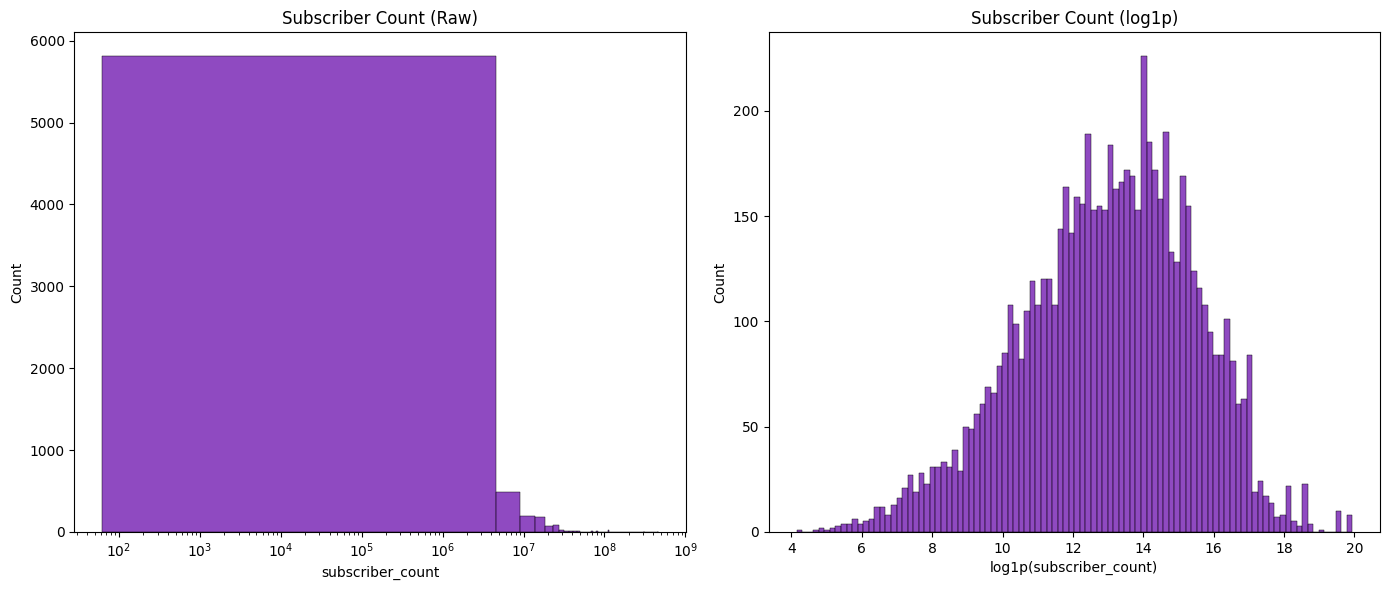

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

purple = "#6A0DAD"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    train["subscriber_count"],
    bins=100,
    ax=axes[0],
    color=purple
)
axes[0].set_xscale("log")
axes[0].set_title("Subscriber Count (Raw)")
axes[0].set_xlabel("subscriber_count")
axes[0].set_ylabel("Count")

sns.histplot(
    np.log1p(train["subscriber_count"]),
    bins=100,
    ax=axes[1],
    color=purple
)
axes[1].set_title("Subscriber Count (log1p)")
axes[1].set_xlabel("log1p(subscriber_count)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


We can clearly see above that the raw distribution is extremely right-skewed , similar analysis can be done for other features like duration,days since video was published etc.

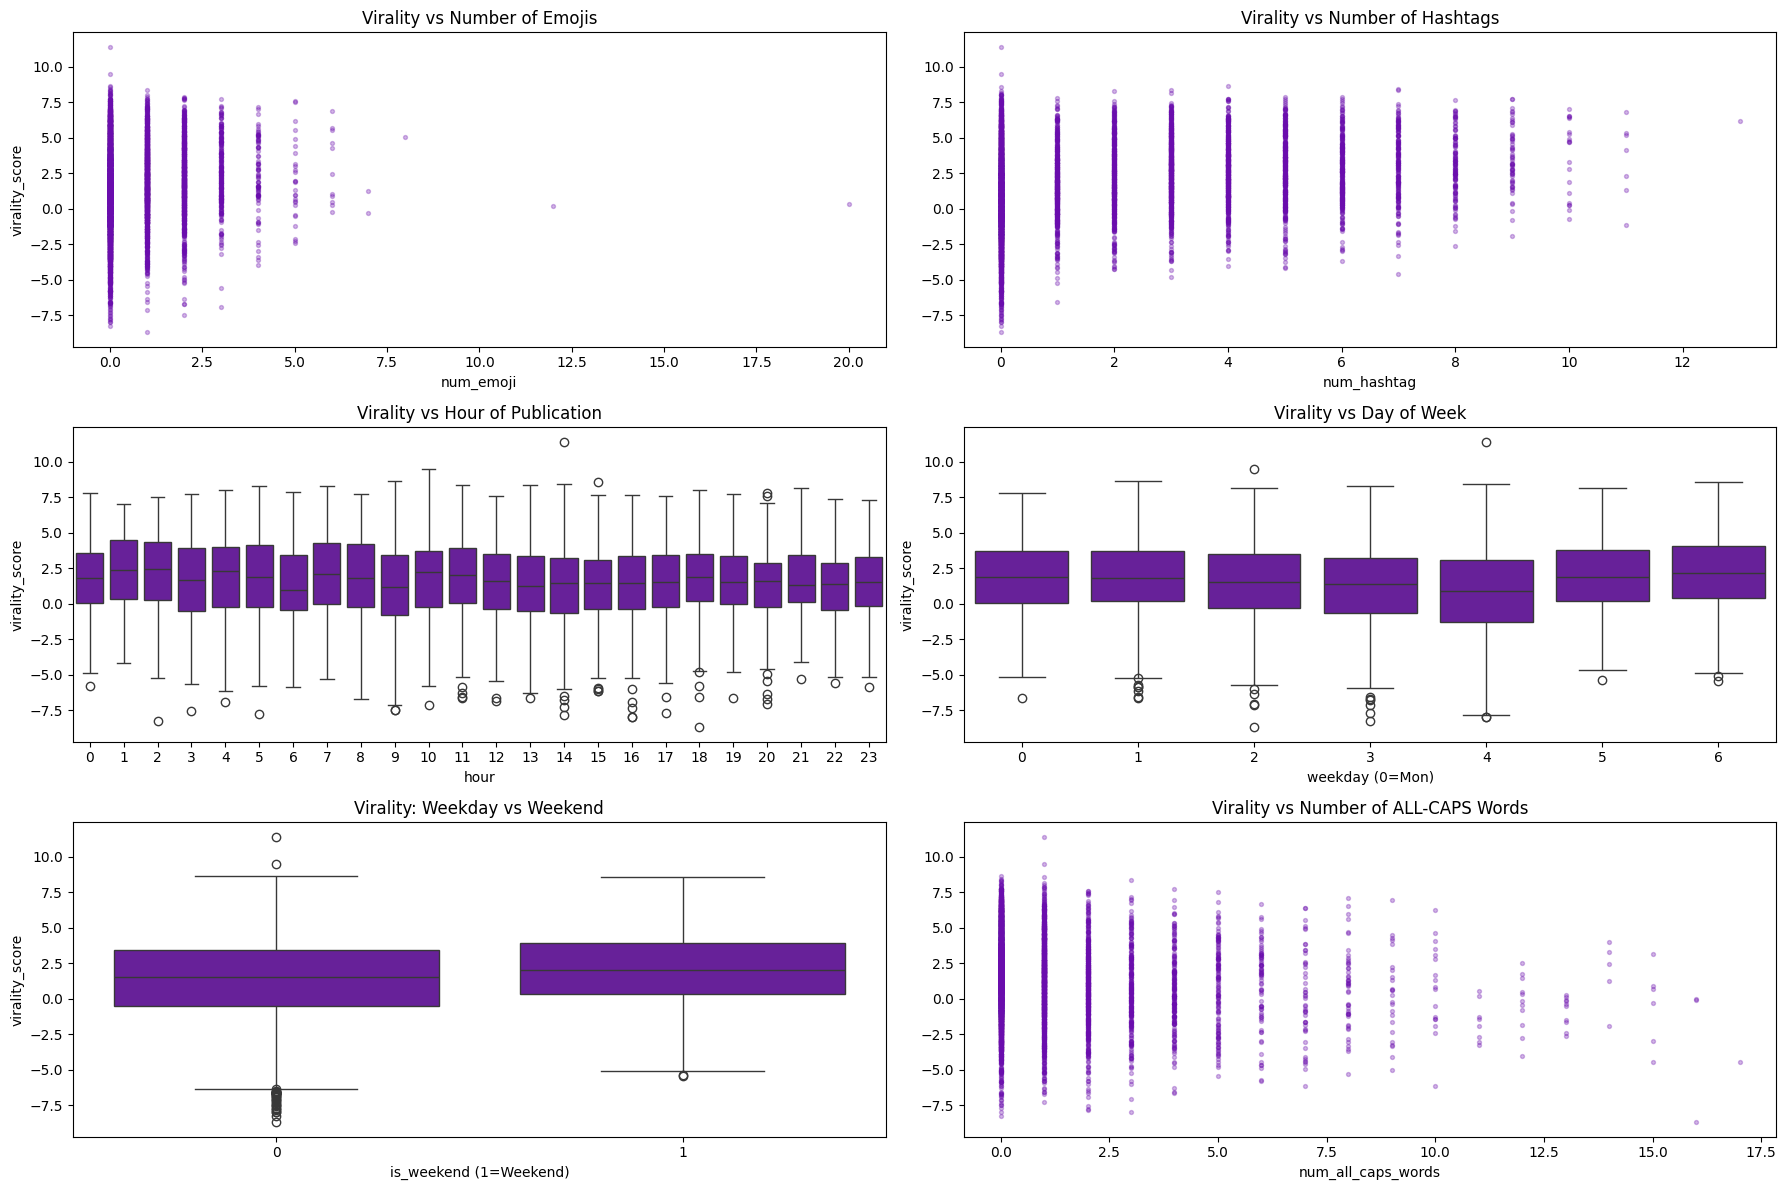

In [6]:
title = train["title"]

num_emoji = title.apply(lambda x: sum(1 for c in x if c in emoji.EMOJI_DATA))
num_hashtag = title.str.count(r"#\w+")

num_all_caps = title.apply(
    lambda s: sum(1 for w in s.split() if w.isupper() and len(w) > 1)
)

t = pd.to_datetime(train["published_at"], utc=True)
is_weekend = (t.dt.dayofweek >= 5).astype(int)

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

# 1. Emojis
axes[0].scatter(num_emoji, train["virality_score"], s=8, alpha=0.3, color=purple)
axes[0].set_title("Virality vs Number of Emojis")
axes[0].set_xlabel("num_emoji")
axes[0].set_ylabel("virality_score")

# 2. Hashtags
axes[1].scatter(num_hashtag, train["virality_score"], s=8, alpha=0.3, color=purple)
axes[1].set_title("Virality vs Number of Hashtags")
axes[1].set_xlabel("num_hashtag")

# 3. Hour of publication
sns.boxplot(
    x=t.dt.hour,
    y=train["virality_score"],
    ax=axes[2],
    color=purple
)
axes[2].set_title("Virality vs Hour of Publication")
axes[2].set_xlabel("hour")

# 4. Day of week
sns.boxplot(
    x=t.dt.dayofweek,
    y=train["virality_score"],
    ax=axes[3],
    color=purple
)
axes[3].set_title("Virality vs Day of Week")
axes[3].set_xlabel("weekday (0=Mon)")

# 5. Weekday vs Weekend
sns.boxplot(
    x=is_weekend,
    y=train["virality_score"],
    ax=axes[4],
    color=purple
)
axes[4].set_title("Virality: Weekday vs Weekend")
axes[4].set_xlabel("is_weekend (1=Weekend)")

# 6. ALL CAPS words
axes[5].scatter(num_all_caps, train["virality_score"], s=8, alpha=0.3, color=purple)
axes[5].set_title("Virality vs Number of ALL-CAPS Words")
axes[5].set_xlabel("num_all_caps_words")

plt.tight_layout()
plt.show()


#### From above we can conclude that :
-  As the number of hashtags/emojis increases the variance of virality decreases and the distribution becomes more tightly clustered and shifts upwards with fewer very low-virality samples.
-  Videos published on weekends exhibit slightly higher median virality and more stable performance, while weekday uploads show greater variance with more extreme low-virality outcomes.
-  Other features also provide some weak but highly non-linear relation which can be used properly by a GB model.



#### Title
 Hand-crafted lexical features such as num_emojis, num_exclamations, and num_all_caps_words capture weak, high-level stylistic signals but are insufficient for modeling the full semantic content of video titles. Titles often express intent, emotion, and context in ways that cannot be represented by simple counts alone.

 Additionally, upon manual inspection I realized that titles could span multiple languages and frequently include emojis and informal expressions. To handle this, I use E5, a multilingual text embedding model trained on large-scale retrieval data across many languages. E5 produces dense semantic representations that are robust to language variation and naturally handle emojis and informal tokens, eliminating the need for aggressive text normalization or emoji removal.

 These embeddings provide a much richer representation of title semantics and complement the weaker handcrafted features in downstream models.

In [ ]:
e5 = SentenceTransformer(
    "intfloat/multilingual-e5-large",
    device = device
)

def encode_titles(titles, batch_size=64):
    titles = ["query: " + str(t) for t in titles]
    emb = e5.encode(
        titles,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True  
    )
    return emb

train_emb = encode_titles(train["title"])
np.save('train_emb.npy',train_emb)

test_emb = encode_titles(test["title"])
np.save('test_emb.npy',test_emb)

del e5
gc.collect()
torch.cuda.empty_cache()

### Additional Text Embeddings

As an ablation, I experimented with adding a second text embedding model to test whether it provides complementary information beyond E5. For this, I used **Qwen-0.6B**, a strong sub-1B open-source model that ranks highly on the MTEB benchmark.

Unlike standard retrieval models, Qwen is **instruction-tuned**, which allows the embedding process to be conditioned on task intent. Instead of embedding titles directly, I used an explicit instruction prompt:

```text
Instruct: Predict the viral potential of a YouTube video title.
Query: <video title>
```

This framing encourages the model to encode features relevant to virality rather than generic semantic similarity.

In [ ]:
qwen = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device=device 
)

def encode_titles_qwen(titles, batch_size=64):
    emb = qwen.encode(
        titles,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        prompt="Instruct: Predict the viral potential of a YouTube video title.\nQuery:"
    )
    return emb

train_emb = encode_titles_qwen(train["title"])
np.save('qwen_train.npy',train_emb)

test_emb = encode_titles_qwen(test["title"])
np.save('qwen_test.npy',test_emb)


### What makes a title viral ?
To qualitatively analyze semantic differences between high- and low-virality titles, we project common n-grams into the same embedding space and measure their alignment with a virality direction defined by the difference between viral and non-viral title centroids. This provides an embedding-based “semantic word cloud” highlighting phrases associated with higher or lower virality, without relying on raw frequency counts.

In [9]:
qwen = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device=device 
)
y = train["virality_score"].values

viral_thresh = np.percentile(y, 75)     # top 25%
nonviral_thresh = np.percentile(y, 25)  # bottom 25%

viral_idx = y >= viral_thresh
nonviral_idx = y <= nonviral_thresh

mu_v = train_emb[viral_idx].mean(axis=0)
mu_nv = train_emb[nonviral_idx].mean(axis=0)

# virality direction( We subtract non-viral centroid from viral centroid )
d = mu_v - mu_nv
d = d / np.linalg.norm(d)  # normalize

# We extract n-grams used in titles
def extract_ngrams(text, n_range=(2,4)):
    tokens = re.findall(r"\b\w+\b", text.lower())
    ngrams = []
    for n in range(n_range[0], n_range[1]+1):
        ngrams.extend(
            [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        )
    return ngrams

ngrams = []
for t in train["title"].fillna("").astype(str):
    ngrams.extend(extract_ngrams(t))

# We filter out and keep frequent ngrams only 
ngram_counts = Counter(ngrams)
ngrams = [g for g, c in ngram_counts.items() if c >= 10]

print(f"Number of candidate n-grams: {len(ngrams)}")


ngram_emb = qwen.encode(
    ngrams,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    prompt="Instruct: Predict the viral potential of a YouTube video title.\nQuery:"
)

scores = np.dot(ngram_emb, d)

ngram_df = pd.DataFrame({
    "ngram": ngrams,
    "score": scores
}).sort_values("score", ascending=False)

del qwen
gc.collect()
torch.cuda.empty_cache()

Number of candidate n-grams: 385


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

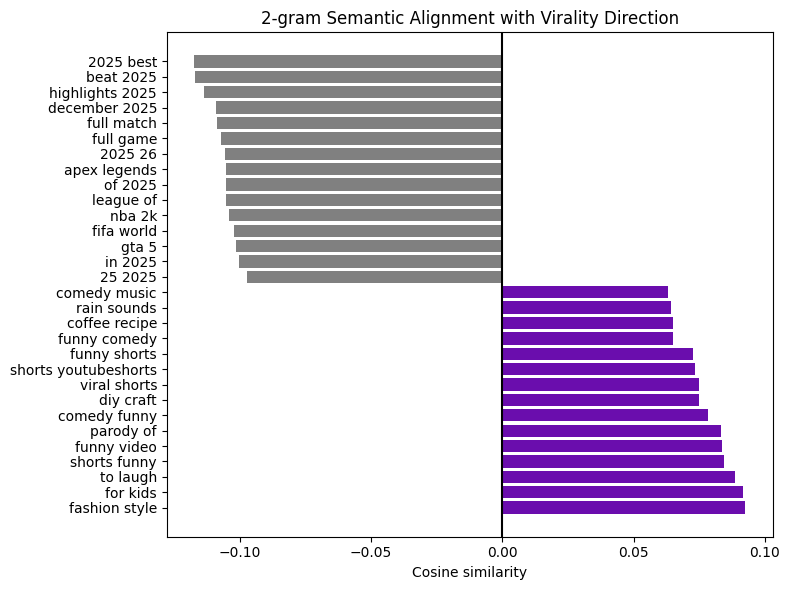

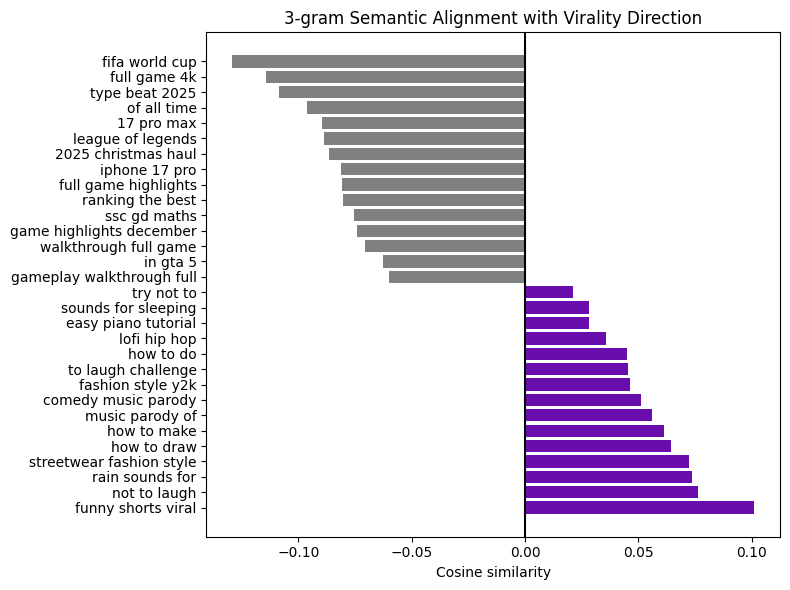

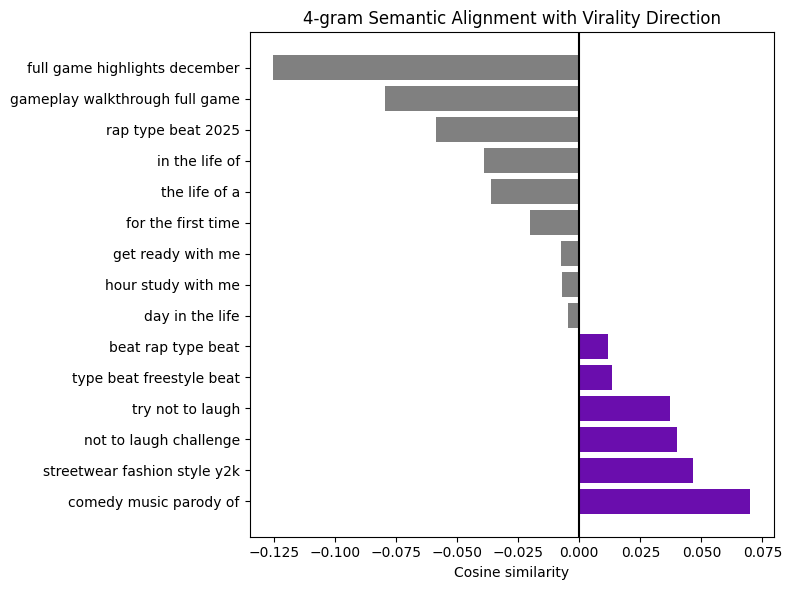

In [10]:
def plot_ngram_alignment(ngram_df, n, top_k=15):
    df_n = ngram_df[ngram_df["ngram"].str.split().str.len() == n]
    
    top = pd.concat([
        df_n.head(top_k),
        df_n.tail(top_k)
    ])

    plt.figure(figsize=(8, 6))
    plt.barh(
        top["ngram"],
        top["score"],
        color=[purple if s > 0 else "gray" for s in top["score"]]
    )
    plt.axvline(0, color="black")
    plt.title(f"{n}-gram Semantic Alignment with Virality Direction")
    plt.xlabel("Cosine similarity")
    plt.tight_layout()
    plt.show()

plot_ngram_alignment(ngram_df, n=2)
plot_ngram_alignment(ngram_df, n=3)
plot_ngram_alignment(ngram_df, n=4)

From the analysis above, we observe that certain recurring video concepts such as “try not to laugh” are aligned with the learned virality direction.

The 2-gram analysis primarily surfaces commonly used hashtag-style phrases that frequently appear in viral content, including “viral shorts”, “fashion style”, and “DIY craft”. These short phrases capture broad topical and stylistic patterns that are characteristic of highly engaging videos.

### Thumbnail Availability and Handling Missing Images

Thumbnail images were downloaded using the provided URLs. Although no URLs were missing in the metadata, a small number of thumbnails could not be retrieved due to broken or inaccessible links at download time. The number of missing thumbnails is reported below.

To handle these cases, missing thumbnails were replaced with a constant empty image (all pixel values set to zero). Additionally, a binary indicator feature was introduced to explicitly mark whether a thumbnail was missing. This allows downstream models to distinguish between genuine visual content and imputed placeholders, rather than treating them identically.


In [ ]:
def save_zero_image(path, size=(224, 224)):
    img = Image.fromarray(np.zeros((size[1], size[0], 3), dtype=np.uint8))
    img.save(path)


def download_thumbnails(df, save_dir, timeout=10):
    ctr = 0
    os.makedirs(save_dir, exist_ok=True)

    session = requests.Session()
    headers = {"User-Agent": "Mozilla/5.0"}

    for _, row in tqdm(df.iterrows(), total=len(df)):
        vid = row["video_id"]
        url = row["thumbnail_url"]
        out_path = os.path.join(save_dir, f"{vid}.jpg")

        if os.path.exists(out_path):
            continue

        try:
            r = session.get(url, headers=headers, timeout=timeout)
            r.raise_for_status()
            
            with open(out_path, "wb") as f:
                f.write(r.content)

        except Exception:
            save_zero_image(out_path)
            ctr+=1
    print(f"missing thumbnails:{ctr}")

download_thumbnails(train, "thumbnails/train")
download_thumbnails(test,  "thumbnails/test")

### Image Embeddings

For visual feature extraction, I used **laion/CLIP-ViT-g-14-laion2B-s12B-b42K** as the image embedding model. This model is trained on a large-scale image–text dataset and provides strong, general-purpose visual representations that capture high-level semantic content in thumbnails.


In [ ]:
clip = CLIPModel.from_pretrained("laion/CLIP-ViT-g-14-laion2B-s12B-b42K")
clip_processor = CLIPProcessor.from_pretrained("laion/CLIP-ViT-g-14-laion2B-s12B-b42K")

clip = clip.to(device)
clip.eval()

def encode_thumbnails_clip(image_dir, video_ids, batch_size=64):
    embeddings = []

    for i in tqdm(range(0, len(video_ids), batch_size)):
        batch_ids = video_ids[i:i+batch_size]
        images = []

        for vid in batch_ids:
            path = os.path.join(image_dir, f"{vid}.jpg")
            img = Image.open(path).convert("RGB")
            images.append(img)

        inputs = clip_processor(
            images=images,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            feats = clip.get_image_features(**inputs)
            feats = feats / feats.norm(dim=1, keepdim=True)

        embeddings.append(feats.cpu().numpy())

    embeddings = np.vstack(embeddings)
    return embeddings

train_img_emb = encode_thumbnails_clip(
    "/kaggle/working/thumbnails/train",
    train["video_id"].tolist()
)

test_img_emb = encode_thumbnails_clip(
    "/kaggle/working/thumbnails/test",
    test["video_id"].tolist()
)

np.save("clip_image_train.npy", train_img_emb)
np.save("clip_image_test.npy", test_img_emb)

del clip
del clip_processor
gc.collect()
torch.cuda.empty_cache()

Similar to the title embeddings, I also experimented with multiple image embedding models. I evaluated several alternatives, including EfficientNet and DINO, but these either failed to improve performance or introduced additional noise. I also attempted to fine-tune EfficientNet; however, due to the relatively small dataset size, this approach quickly overfit and did not generalize well.

Ultimately, I used **google/siglip-so400m-patch14-384** as the image embedding model, which provided complementary visual representations and resulted in a consistent improvement in RMSE.

In [ ]:
siglip_processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")
siglip = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")

model = siglip.to(device)
model.eval()

def encode_thumbnails_siglip(image_dir, video_ids, batch_size=32):
    embeddings = []

    for i in tqdm(range(0, len(video_ids), batch_size)):
        batch_ids = video_ids[i:i+batch_size]
        images = []

        for vid in batch_ids:
            path = os.path.join(image_dir, f"{vid}.jpg")
            img = Image.open(path).convert("RGB")
            images.append(img)

        inputs = siglip_processor(
            images=images,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            feats = model.get_image_features(**inputs)
            feats = feats / feats.norm(dim=1, keepdim=True)

        embeddings.append(feats.cpu().numpy())

    embeddings = np.vstack(embeddings)
    return embeddings

train_img_emb = encode_thumbnails_siglip(
    "/kaggle/working/thumbnails/train",
    train["video_id"].tolist()
)

test_img_emb = encode_thumbnails_siglip(
    "/kaggle/working/thumbnails/test",
    test["video_id"].tolist()
)

np.save("siglip_train.npy", train_img_emb)
np.save("siglip_test.npy", test_img_emb)

del siglip
del siglip_processor
gc.collect()
torch.cuda.empty_cache()

Finally, all text and image embeddings were reduced to 50 dimensions using PCA. I experimented with both lower (30) and higher (64) dimensionalities; however, lower dimensions tended to under-represent the information content, while higher dimensions introduced additional noise. Empirically, 50 dimensions provided the best trade-off and consistently delivered the strongest validation performance.

In addition to learned image embeddings, I included a small set of low-level visual features : average brightness, saturation, and edge density to capture coarse thumbnail properties such as color intensity and visual complexity. These features alone are weak predictors, but they provide complementary signals to deep embeddings and slightly improved ensemble stability.

In [ ]:
def extract_thumbnail_features(img_path):
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)

    hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
    brightness = hsv[:, :, 2].mean()
    saturation = hsv[:, :, 1].mean()

    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edge_density = edges.mean() / 255.0  

    return {
        "brightness": brightness,
        "saturation": saturation,
        "edge_density": edge_density
    }

def build_thumbnail_df(df, img_dir):
    rows = []

    for vid in df["video_id"]:
        img_path = os.path.join(img_dir, f"{vid}.jpg")
        feats = extract_thumbnail_features(img_path)
        rows.append(feats)

    return pd.DataFrame(rows, index=df.index)

X_thumbnail_train = build_thumbnail_df(train,'/kaggle/working/thumbnails/train')
X_thumbnail_test = build_thumbnail_df(test,'/kaggle/working/thumbnails/test')

In [ ]:
pca = PCA(n_components=50, random_state=42)

train_emb = np.load('/kaggle/working/train_emb.npy')
test_emb = np.load('/kaggle/working/test_emb.npy')
qwen_train =np.load('/kaggle/working/qwen_train.npy')
qwen_test =np.load('/kaggle/working/qwen_test.npy')
train_img_emb = np.load('/kaggle/working/clip_image_train.npy')
test_img_emb = np.load('/kaggle/working/clip_image_test.npy')
sig_train = np.load('/kaggle/working/siglip_train.npy')
sig_test = np.load('/kaggle/working/siglip_test.npy')


train_pca = pca.fit_transform(train_emb)
test_pca = pca.transform(test_emb)

qwen_train_pca = pca.fit_transform(qwen_train)
qwen_test_pca = pca.transform(qwen_test)

train_img_emb_pca = pca.fit_transform(train_img_emb)
test_img_emb_pca  = pca.transform(test_img_emb)

sig_train_pca = pca.fit_transform(sig_train)
sig_test_pca  = pca.transform(sig_test)


### Final Feature Set

**Temporal Features**  
Time-based features (hour, weekday, month) are encoded using **cyclical encodings** (`sin`, `cos`) to preserve periodic structure (e.g., 23:00 ≈ 00:00).

**Title-Level Signals**  
I include simple lexical features such as:
- Number of question marks and exclamation marks  
- Number of emojis and hashtags  
- Number of fully capitalized words  

These capture explicit attention-grabbing and clickbait-style patterns that are often weakly represented in embeddings.

**Sentiment Feature**  
I add the VADER compound sentiment score (`polarity_scores["compound"]`) for each title.  
This provides an explicit measure of emotional polarity and intensity, which complements dense embeddings by directly modeling affective cues linked to click-through behavior.

**Target Encoding**  
Target encoding is applied to quantile-binned (5 bins) versions of:
- `subscriber_count`
- `duration`
- `days_since_publish`

For each bin, fold-wise statistics (`mean`, `std`, `count`, `min`, `max`) of the target are computed and used as features, allowing the model to capture non-linear distributional effects while avoiding leakage.


In [ ]:
analyzer = SentimentIntensityAnalyzer()

def make_features(df, title_emb, img_emb,sig_emb,qwen_emb,X_thumbnail):
    """Create base features (without target encoding)"""
    t_ref = pd.to_datetime(df["published_at"], utc=True).max()
    t = pd.to_datetime(df["published_at"], utc=True)
    title = df["title"].fillna("")

    hashtags = df["title"].str.findall(r"#\w+")

    
    X = pd.DataFrame(index=df.index)
    
    X["log_subs"] = np.log1p(df["subscriber_count"])
    X["log_duration"] = np.log1p(df["duration"])
    X["log_days_since_publish"] = np.log1p((t_ref - t).dt.days)
    X["channel_activity"] = X["log_subs"] * X["log_days_since_publish"]
    X["num_hashtag"] = hashtags.apply(len)
    X["num_emoji"] = df["title"].apply(lambda x: len([c for c in str(x) if c in emoji.EMOJI_DATA]))
    X["is_weekend"] = (t.dt.dayofweek >= 5).astype(int)
    X["year"] = t.dt.year
    X['hour_sin'] = np.sin(2*np.pi * t.dt.hour / 24)
    X['hour_cos'] = np.cos(2*np.pi * t.dt.hour / 24)
    X['weekday_sin'] = np.sin(2*np.pi * t.dt.day / 7)
    X['weekday_cos'] = np.cos(2*np.pi * t.dt.day / 7)
    X['month_cos'] = np.cos(2*np.pi * t.dt.month /12)
    X['month_sin'] = np.sin(2*np.pi * t.dt.month /12)
    X['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
    X["num_exclamation"] = title.str.count("!")
    X["num_question"] = title.str.count(r"\?")

    X["num_all_caps_words"] = df["title"].fillna("").apply(
        lambda s: sum(1 for w in s.split() if w.isupper() and len(w) > 1)
    )
    X["title_sentiment"] = df["title"].apply(
        lambda x: analyzer.polarity_scores(str(x))["compound"]
    )

        # ===== Binning for Target Encoding (using qcut for all) =====
    X["sub_tier"] = pd.qcut(df["subscriber_count"], q=5, labels=False, duplicates='drop')
    
    X["duration_bin"] = pd.qcut(df["duration"], q=5, labels=False, duplicates='drop')
    
    X["days_bin"] = pd.qcut((t_ref - t).dt.days, q=5, labels=False, duplicates='drop')
        
    X_title = pd.DataFrame(
        title_emb, 
        index=df.index, 
        columns=[f"title_emb_{i}" for i in range(title_emb.shape[1])]
    )
    X_qwen = pd.DataFrame(
        qwen_emb, 
        index=df.index, 
        columns=[f"qwen_emb_{i}" for i in range(qwen_emb.shape[1])]
    )
    X_img = pd.DataFrame(
        img_emb, 
        index=df.index, 
        columns=[f"img_emb_{i}" for i in range(img_emb.shape[1])]
    )
    X_sig = pd.DataFrame(
        sig_emb, 
        index=df.index, 
        columns=[f"sig_emb_{i}" for i in range(sig_emb.shape[1])]
    )

    X = pd.concat([X, X_title, X_img,X_sig, X_qwen,X_thumbnail], axis=1)
    return X


def add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols):

    for col in categorical_cols:
        # Compute statistics on training fold only
        stats_df = pd.DataFrame({col: X_tr[col], 'target': y_tr})
        agg_stats = stats_df.groupby(col)['target'].agg(['mean', 'std', 'count','min','max']).reset_index()
        
        # Create mappings
        mean_map = agg_stats.set_index(col)['mean']
        std_map = agg_stats.set_index(col)['std']
        count_map = agg_stats.set_index(col)['count']
        min_map = agg_stats.set_index(col)['min']
        max_map = agg_stats.set_index(col)['max']

        
        for df_ in [X_tr, X_val, X_te]:
            df_[f"{col}_te_mean"] = df_[col].map(mean_map).fillna(y_tr.mean())
            df_[f"{col}_te_std"] = df_[col].map(std_map).fillna(y_tr.std())
            df_[f"{col}_te_count"] = df_[col].map(count_map).fillna(0)
            df_[f"{col}_te_min"] = df_[col].map(min_map).fillna(0)
            df_[f"{col}_te_max"] = df_[col].map(max_map).fillna(0)

    
    # Drop original categorical columns
    X_tr.drop(categorical_cols, axis=1, inplace=True)
    X_val.drop(categorical_cols, axis=1, inplace=True)
    X_te.drop(categorical_cols, axis=1, inplace=True)
    
    return X_tr, X_val, X_te


In [ ]:
X_train = make_features(train,train_pca,train_img_emb_pca,sig_train_pca,qwen_train_pca,X_thumbnail_train)
y = train["virality_score"]
X_test = make_features(test,test_pca,test_img_emb_pca,sig_test_pca,qwen_test_pca,X_thumbnail_test)

### Model Training and Ensembling

All models are trained using **5-fold cross-validation** to ensure robust out-of-fold predictions.

The final solution is an ensemble of **seven diverse models**:
- LightGBM  
- LightGBM (DART)  
- XGBoost  
- CatBoost  
- Random Forest Regressor  
- RealMLP  
- LightAutoML (LAMA)

Each model contributes out-of-fold predictions, which are then combined using a **Ridge Regression** meta-learner.

I experimented with alternative ensembling strategies such as hill climbing and tree-based stackers (XGBoost / LightGBM), but Ridge regression proved to be the most stable and effective for this task, likely due to its ability to regularize highly correlated model outputs.


 ### LightGBM

In [ ]:
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X_train))
test_pred_lgb = np.zeros(len(X_test))

# Categorical columns for target encoding
categorical_cols = ['sub_tier', 'duration_bin', 'days_bin']

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    X_tr, X_val, X_te = add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols)
    
    feature_names = X_tr.columns
    
    model = LGBMRegressor(
        n_estimators=2500,
        learning_rate=0.01,
        num_leaves=100,
        subsample=0.85,
        colsample_bytree=0.70,
        objective="regression", 
        random_state=42,
        verbose =1

    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100) 
    ]
    )
    
    oof_lgb[val_idx] = model.predict(X_val)
    test_pred_lgb += model.predict(X_te) / N_SPLITS
    
    
    fold_rmse = root_mean_squared_error(y_val, oof_lgb[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_lgb)
print(f"Final CV RMSE: {cv_rmse:.4f}")


### LightGBM(dart)

In [ ]:
oof_lgb_dart = np.zeros(len(X_train))
test_pred_lgb_dart = np.zeros(len(X_test))


for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    X_tr, X_val, X_te = add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols)
    
    feature_names = X_tr.columns
    
    model = LGBMRegressor(
        boosting_type='dart',
        n_estimators=6500,
        learning_rate=0.02,
        max_depth=7,
        subsample=0.70,
        colsample_bytree=0.60,
        objective="regression", 
        random_state=42,
        verbose = 0

    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
        lgb.log_evaluation(period=100) 
    ]
    )
    
    oof_lgb_dart[val_idx] = model.predict(X_val)
    test_pred_lgb_dart += model.predict(X_te) / N_SPLITS
    
    
    fold_rmse = root_mean_squared_error(y_val, oof_lgb_dart[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_lgb_dart)
print(f"Final CV RMSE: {cv_rmse:.4f}")


### XGBoost

In [ ]:
oof_xgb = np.zeros(len(X_train))
test_pred_xgb = np.zeros(len(X_test))


for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    X_tr, X_val, X_te = add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols)
    
    feature_names = X_tr.columns
    
    X_tr_arr = X_tr.values
    X_val_arr = X_val.values
    X_te_arr = X_te.values
    
    # XGBoost Regressor
    model = xgb.XGBRegressor(
        n_estimators=5000,
        learning_rate=0.007,
        max_depth=6,
        subsample=0.64,
        colsample_bytree=0.88,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )
    
    model.fit(
        X_tr_arr, y_tr,
        eval_set=[(X_val_arr, y_val)],
        verbose=100
    )
    
    oof_xgb[val_idx] = model.predict(X_val_arr)
    test_pred_xgb += model.predict(X_te_arr) / N_SPLITS
    
   
    fold_rmse = root_mean_squared_error(y_val, oof_xgb[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_xgb)

print(f"Final CV RMSE: {cv_rmse:.4f}")


### CatBoost

In [ ]:
oof_cat = np.zeros(len(X_train))
test_pred_cat = np.zeros(len(X_test))


for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    X_tr, X_val, X_te = add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols)
    
    feature_names = X_tr.columns
    
    
    model = CatBoostRegressor(
        iterations=6500,
        learning_rate=0.01,
        depth=6,
        subsample=0.8,
        colsample_bylevel=0.8,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_state=42,
        early_stopping_rounds=200,
        verbose=100,
        thread_count=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    oof_cat[val_idx] = model.predict(X_val)
    test_pred_cat += model.predict(X_te) / N_SPLITS
    
    
    fold_rmse = root_mean_squared_error(y_val, oof_cat[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_cat)

print(f"Final CV RMSE: {cv_rmse:.4f}")


### Random Forest Regressor 

In [ ]:
oof_rf = np.zeros(len(X_train))
test_pred_rf = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    X_tr, X_val, X_te = add_target_encoding(X_tr, X_val, X_te, y_tr, categorical_cols)
    
    model = RandomForestRegressor(
        n_estimators=3000,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    model.fit(X_tr, y_tr)
    
    oof_rf[val_idx] = model.predict(X_val)
    test_pred_rf += model.predict(X_te) / N_SPLITS
    
    fold_rmse = root_mean_squared_error(y_val, oof_rf[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_rf)
print(f"Final CV RMSE: {cv_rmse:.4f}")

### RealMLP

In [ ]:
oof_realmlp = np.zeros(len(X_train))
test_pred_realmlp = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    
    model = RealMLP_TD_Regressor(
        random_state=42,
        device=device  
    )
    
    model.fit(X_tr, y_tr)
    
    oof_realmlp[val_idx] = model.predict(X_val)
    test_pred_realmlp += model.predict(X_te) / N_SPLITS
    
    fold_rmse = root_mean_squared_error(y_val, oof_realmlp[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_realmlp)
print(f"Final CV RMSE: {cv_rmse:.4f}")


### LightAutoML (LAMA)

In [ ]:
oof_lama = np.zeros(len(X_train))
test_pred_lama = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    
    task = Task('reg', metric='mse')
    
    model = TabularAutoML(
        task=task,
        timeout=600,
        cpu_limit=-1,
        reader_params={
        "n_jobs": 1,
        "advanced_roles": False
    },
        general_params={'use_algos': [['linear_l2', 'lgb', 'cb']]},
    )
    
    X_tr_lama = X_tr.copy()
    X_tr_lama["target"] = y_tr.values

    model.fit_predict(
        X_tr_lama,
        roles={"target": "target"}
    )
    
    oof_lama[val_idx] = model.predict(X_val).data[:, 0]
    test_pred_lama += model.predict(X_te).data[:, 0] / N_SPLITS
    
    fold_rmse = root_mean_squared_error(y_val, oof_lama[val_idx])
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

cv_rmse = root_mean_squared_error(y, oof_lama)
print(f"Final CV RMSE: {cv_rmse:.4f}")

### Ridge

In [ ]:
X_meta_train = np.column_stack([oof_lgb,oof_lgb_dart, oof_xgb,oof_cat,oof_rf,oof_realmlp,oof_lama])
X_meta_test  = np.column_stack([test_pred_lgb,test_pred_lgb_dart, test_pred_xgb,test_pred_cat,test_pred_rf,test_pred_realmlp,test_pred_lama])


ridge = Ridge(alpha=1.0)  
ridge.fit(X_meta_train, y)

oof_stack = ridge.predict(X_meta_train)
rmse = root_mean_squared_error(y, oof_stack)
print("Stacked CV RMSE:", rmse) 

In [ ]:
print(ridge.coef_)
test_stack = ridge.predict(X_meta_test)
submission = pd.DataFrame({
    "video_id": test["video_id"],
    "virality_score": test_stack
})
submission.to_csv("submission.csv", index=False)


In [ ]:
sub = pd.read_csv("/kaggle/working/submission.csv")
sol = pd.read_csv("/kaggle/input/solution/solution.csv")

y_true = sol["virality_score"].values
y_pred = sub["virality_score"].values

print(f"RMSE on full data: {root_mean_squared_error(y_true, y_pred):.5f}")